---
title: Maps that answer regional questions
short_title: 15 · Pathwise sampling
subtitle: Joint posterior draws over a field, via Matheron's rule
---

# The question a marginal map cannot answer

Notebook 07 produced the curriculum's most useful picture: the 100-year return
level interpolated across Iberia, with an uncertainty band that tightens near
stations and widens into the gaps. It was built the ordinary way — condition the
GP, then ask for the predictive mean and variance at every grid cell.

That gives a **marginal** answer per cell: at *this* point, the level is
such-and-such give or take so much. Stack them up and you have a map of
pointwise intervals.

Now ask the question a risk assessment actually asks:

> What is the probability that the 100-year level exceeds 49 degC
> **somewhere** in southern Iberia?

Nothing in a marginal map can answer it. The event spans cells, and to reason
about it you need to know whether the cells rise and fall *together*. Marginals
deliberately throw that away — and the two obvious workarounds are both wrong:
taking the largest per-cell probability understates the risk, while multiplying
the per-cell probabilities as if they were independent wildly overstates it.

What you need is **joint** draws: whole plausible fields, each one internally
consistent. `pyrox-gp` provides them through `PathwiseSampler`, which implements
Matheron's rule — draw from the prior with random Fourier features, then apply a
correction that conditions the whole function on the data at once.


In [1]:
from __future__ import annotations

import time
import warnings

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid", context="notebook")

import numpyro
from pyrox_gp import GPPrior, Matern, PathwiseSampler
from xtremax import gev_return_level
from spatial_extremes import data, results
from spatial_extremes.viz import iberia_axes, scatter_field

## The field to sample from

We reuse notebook 07's fitted location field rather than refitting: its cached
per-station posterior median is the surface we interpolate, with the shared
scale and shape that turn a location into a return level.

One honest limitation to state up front. Conditioning on the *median* field
means the paths below carry the **interpolation** uncertainty — what the GP does
not know between stations — but not the posterior uncertainty in the field
itself. The joint-versus-marginal contrast, which is the point of this notebook,
is unaffected: both sides inherit the same limitation.


In [2]:
maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
S = stations.shape[0]
Xm, Xsd = stations.mean(0), stations.std(0)
Xn = jnp.asarray((stations - Xm) / Xsd)

fit = results.load_fit("spatial_gp_mu", expect_real=is_real)
if fit is None:
    raise RuntimeError("run notebook 07 first: this notebook samples its fitted field")

mu_obs = jnp.asarray(fit["mu_field_med"])
SIGMA, XI = float(fit["sigma_med"]), float(fit["xi_med"])
LS = float(fit["lengthscale"])
print(results.describe_fit(fit))
print("source:", "REAL CDS" if is_real else "synthetic",
      f"| {S} stations | sigma {SIGMA:.2f} degC | xi {XI:+.3f}")

mu_bar = float(jnp.mean(mu_obs))
kernel = Matern(nu=1.5, init_lengthscale=LS, init_variance=float(jnp.var(mu_obs)))
prior = GPPrior(kernel=kernel, X=Xn,
                mean_fn=lambda Xq: jnp.full(Xq.shape[0], mu_bar))
NOISE = 0.35     # station-level nugget, degC

G = 45
glon = np.linspace(-9.5, 3.5, G)
glat = np.linspace(36.0, 43.8, G)
GX, GY = np.meshgrid(glon, glat)
grid = np.column_stack([GX.ravel(), GY.ravel()])
gridn = jnp.asarray((grid - Xm) / Xsd)
print(f"prediction grid: {G}x{G} = {grid.shape[0]} cells over Iberia")

warm start <- notebooks/03_spatial_gev/07_spatial_gp_mu.ipynb @ 28243b1 (2026-08-21T17:37:52+00:00)
source: REAL CDS | 107 stations | sigma 1.96 degC | xi -0.205
prediction grid: 45x45 = 2025 cells over Iberia


## Two ways to ask the GP what it thinks

`predict` returns the marginal mean and variance per cell. `PathwiseSampler`
returns callable **functions**: each draw is a complete field, and evaluating it
anywhere gives values that are consistent with each other.

A first check is that they agree where they should. Averaged over enough paths,
the pathwise mean and standard deviation must reproduce the marginal ones — if
they do not, the sampler is wrong. What the paths add is everything the
marginals discard: the correlations *between* cells.


In [3]:
N_PATHS = 400
with numpyro.handlers.seed(rng_seed=0):
    cond = prior.condition(mu_obs, jnp.asarray(NOISE))

    t0 = time.time()
    gmean, gvar = cond.predict(gridn)
    t_marginal = time.time() - t0

    t0 = time.time()
    sampler = PathwiseSampler(cond, n_features=512)
    paths = sampler.sample_paths(jr.PRNGKey(1), n_paths=N_PATHS)
    F = np.asarray(paths(gridn))                    # (n_paths, n_cells)
    t_pathwise = time.time() - t0

gm, gs = np.asarray(gmean), np.asarray(jnp.sqrt(gvar))
print(f"marginal predict : {t_marginal:5.2f}s")
print(f"{N_PATHS} joint paths : {t_pathwise:5.2f}s   -> array {F.shape}")
print(f"\nagreement (Monte Carlo error at {N_PATHS} paths):")
print(f"  max |path mean - marginal mean| = {np.abs(F.mean(0) - gm).max():.3f} degC")
print(f"  max |path sd   - marginal sd  | = {np.abs(F.std(0) - gs).max():.3f} degC")

marginal predict :  1.49s
400 joint paths :  9.87s   -> array (400, 2025)

agreement (Monte Carlo error at 400 paths):
  max |path mean - marginal mean| = 0.267 degC
  max |path sd   - marginal sd  | = 0.316 degC


### What a band hides

Take a west-to-east transect across central Iberia. The shaded band is the
marginal $\pm 2$ standard deviations — the picture notebook 07 draws. The lines
are individual posterior paths.

Every path stays inside the band, so the band is not wrong. But no path wanders
across it freely: each is a smooth field that is high *in a region* or low *in a
region*. The band describes where the surface might be at each point taken
alone; the paths describe which surfaces are plausible as a whole. Those are
different objects, and only the second can answer a question about a region.


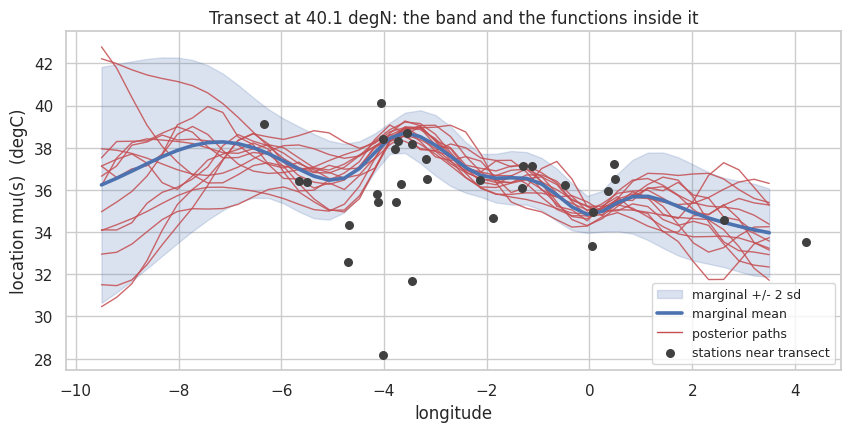

In [4]:
lat_target = 40.0
row = int(np.argmin(np.abs(glat - lat_target)))
sel = np.arange(row * G, (row + 1) * G)
x_axis = glon

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.fill_between(x_axis, gm[sel] - 2 * gs[sel], gm[sel] + 2 * gs[sel],
                color="#4C72B0", alpha=0.20, label="marginal +/- 2 sd")
for i in range(14):
    ax.plot(x_axis, F[i, sel], lw=1.0, alpha=0.85, color="#C44E52")
ax.plot(x_axis, gm[sel], lw=2.6, color="#4C72B0", label="marginal mean")
ax.plot([], [], lw=1.0, color="#C44E52", label="posterior paths")
near = np.abs(stations[:, 1] - glat[row]) < 1.0
ax.scatter(stations[near, 0], np.asarray(mu_obs)[near], s=30, zorder=5,
           color="0.25", label="stations near transect")
ax.set(xlabel="longitude", ylabel="location mu(s)  (degC)",
       title=f"Transect at {glat[row]:.1f} degN: the band and the functions inside it")
ax.legend(fontsize=9, loc="lower right")
plt.show()

## The regional question

Now the question that motivated all this. Turn each path into a 100-year return
level, pick a threshold, and ask how often *any* cell in southern Iberia exceeds
it.

Three numbers, and only one of them is right:

- **Joint** — the fraction of whole paths whose regional maximum exceeds the
  threshold. This is the answer.
- **Independence** — what you get by treating the per-cell probabilities as
  independent, $1-\prod_c (1-p_c)$. This is the trap: with hundreds of highly
  correlated cells it approaches certainty almost regardless of the data.
- **Largest single cell** — the biggest per-cell marginal probability, the most
  a marginal map can honestly offer. It understates the regional risk, because
  the exceedance could happen elsewhere.


In [5]:
THRESHOLD = 49.0                      # degC
region = grid[:, 1] < 38.5            # southern Iberia
n_cells = int(region.sum())

z_paths = np.asarray(gev_return_level(100.0, jnp.asarray(F), SIGMA, XI))
z_mean_map = np.asarray(gev_return_level(100.0, jnp.asarray(gm), SIGMA, XI))

regional_max = z_paths[:, region].max(1)
p_joint = float((regional_max > THRESHOLD).mean())
p_cell = (z_paths[:, region] > THRESHOLD).mean(0)
p_indep = float(1.0 - np.prod(1.0 - p_cell))
p_max_cell = float(p_cell.max())
eff = np.log1p(-p_joint) / np.log1p(-p_max_cell)

print(f"P(100-year level > {THRESHOLD:.0f} degC somewhere in southern Iberia)")
print(f"  joint, from whole paths        {p_joint:6.3f}   <- the answer")
print(f"  assuming cells independent     {p_indep:6.3f}   <- overstates")
print(f"  largest single-cell probability{p_max_cell:6.3f}   <- understates")
print(f"\n{n_cells} grid cells in the region, but they behave like about "
      f"{eff:.1f} independent ones.")

P(100-year level > 49 degC somewhere in southern Iberia)
  joint, from whole paths         0.393   <- the answer
  assuming cells independent      0.985   <- overstates
  largest single-cell probability 0.163   <- understates

675 grid cells in the region, but they behave like about 2.8 independent ones.


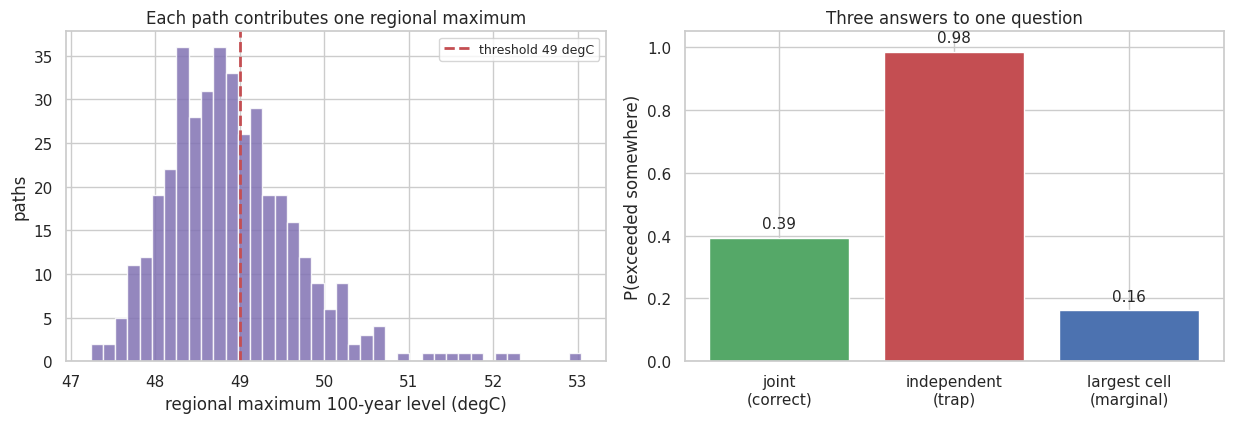

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].hist(regional_max, bins=40, color="#8172B3", alpha=0.85)
axes[0].axvline(THRESHOLD, color="#C44E52", lw=2, ls="--",
                label=f"threshold {THRESHOLD:.0f} degC")
axes[0].set(xlabel="regional maximum 100-year level (degC)", ylabel="paths",
            title="Each path contributes one regional maximum")
axes[0].legend(fontsize=9)

axes[1].bar(["joint\n(correct)", "independent\n(trap)", "largest cell\n(marginal)"],
            [p_joint, p_indep, p_max_cell],
            color=["#55A868", "#C44E52", "#4C72B0"])
axes[1].set(ylabel="P(exceeded somewhere)", ylim=(0, 1.05),
            title="Three answers to one question")
for i, v in enumerate([p_joint, p_indep, p_max_cell]):
    axes[1].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=11)
fig.tight_layout()
plt.show()

### Sensitivity to the threshold

The gap is not a quirk of one number. As the threshold rises the event gets
rarer, per-cell probabilities shrink — and the independence assumption gets
*worse*, not better, because it keeps multiplying many small numbers that are in
truth almost the same number.


In [7]:
rows = []
for th in (47.0, 48.0, 49.0, 50.0, 51.0):
    pj = float((z_paths[:, region].max(1) > th).mean())
    pc = (z_paths[:, region] > th).mean(0)
    rows.append({"threshold (degC)": th, "joint": pj,
                 "independence": float(1.0 - np.prod(1.0 - pc)),
                 "largest cell": float(pc.max())})

import pandas as pd
print(pd.DataFrame(rows).to_string(index=False,
      float_format=lambda v: f"{v:8.3f}"))

 threshold (degC)    joint  independence  largest cell
           47.000    1.000         1.000         0.963
           48.000    0.907         1.000         0.583
           49.000    0.393         0.985         0.163
           50.000    0.083         0.445         0.022
           51.000    0.020         0.146         0.007


## What a single draw looks like

The mean map is the average of every plausible field, so it is smoother than any
field the model actually believes in. Individual paths are rougher, and they
disagree with each other in whole regions at a time — which is exactly the
structure the regional calculation depends on.


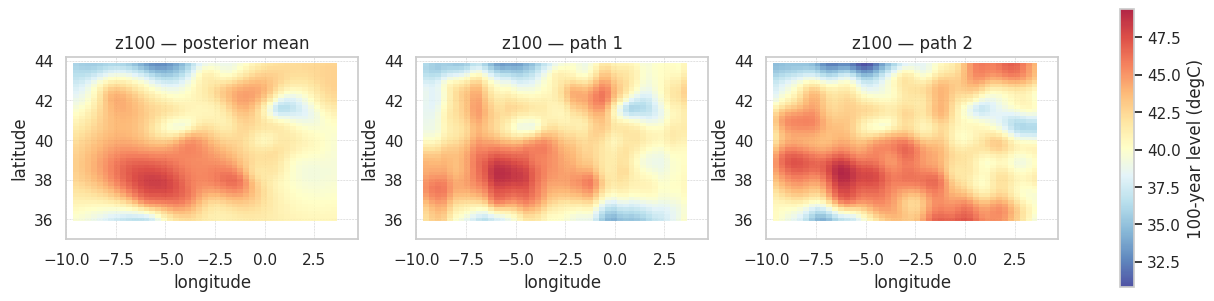

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
panels = [("posterior mean", z_mean_map),
          ("path 1", z_paths[0]),
          ("path 2", z_paths[1])]
vmin = min(p[1].min() for p in panels)
vmax = max(p[1].max() for p in panels)
for ax, (title, vals) in zip(axes, panels):
    ax = iberia_axes(ax=ax)
    kw = {}
    if getattr(ax, "_is_geo", False):        # same guard viz.py uses
        import cartopy.crs as ccrs
        kw["transform"] = ccrs.PlateCarree()
    pc = ax.pcolormesh(GX, GY, vals.reshape(G, G), cmap="RdYlBu_r",
                       vmin=vmin, vmax=vmax, alpha=0.85, shading="auto", **kw)
    ax.set_title(f"z100 — {title}")
fig.colorbar(pc, ax=axes, shrink=0.75, label="100-year level (degC)")
plt.show()

## Takeaway

**Marginal maps and joint draws answer different questions.** A per-cell
interval is the right object for "how hot might it get *here*". It is the wrong
object — not merely imprecise, but unable in principle — for "how hot might it
get *anywhere in this region*", because that question is about how the cells
move together and marginals discard exactly that.

**The independence shortcut is worse than doing nothing.** Multiplying per-cell
probabilities turned a 0.39 risk into 0.99, and the error grows as the threshold
rises and the event gets rarer: by 51 degC it overstates a 1-in-50 chance by a
factor of seven. Hundreds of grid cells over a
smooth field carry only a couple of independent numbers between them; treating
them as hundreds of separate coin flips manufactures confidence that is not
there.

**Pathwise sampling is cheap.** Matheron's rule cost a few seconds for hundreds
of full-field draws — comparable to the marginal call it supplements, and the
paths reproduce the marginal mean and standard deviation to within Monte Carlo
error, which is the check that they are the same posterior seen a different way.

The practical upshot for the rest of the curriculum: notebook 07's map is right
about what it claims, and it should keep its band. But any statement that ranges
over an area — a regional design value, an exceedance probability, an expected
number of affected stations — should be computed from paths, not from the band.

### Where this leaves the Improvements section

Three threads from the survey are now tested. **Notebook 13** found the
approximation, not the optimiser, governs the quality of these fits, and that a
bounded tail rules out the variational family outright. **Notebook 14** found
that coregionalization does not rescue the shape field, because the data never
identified the cross-field structure in the first place. This notebook adds a
capability rather than correcting one — and unlike the other two, it works about
as well as hoped.
